<a href="https://colab.research.google.com/github/keshav123333/LLM_From_Scratch_BUILD/blob/main/llm_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
with open("/content/the-verdict.txt") as f:
  raw_text=f.read()

In [ ]:
len(raw_text)

20479

In [ ]:
import re
processed=re.split(r'([,.*:;?_!"()\'\|+]|--|\s+)',raw_text)
result=[items.strip() for items in processed if items.strip()]

In [ ]:
dic=sorted(set(result))
dic.extend(["<|endoftext|>","<|unk|>"])

In [ ]:
vocab={words:no for no,words in enumerate(dic)}


In [ ]:
class SimpleTokenizer:
  def __init__(self,vocab):
    self.str_to_int=vocab
    self.int_to_str={v:k for k,v in vocab.items()}


  def encode(self,text):
    processed=re.split(r'([,.*:;?_!"()\'\|+]|--|\s+)',text)
    processed=[items.strip() for items in processed if items.strip()]
    result=[self.str_to_int[token] if token in self.str_to_int else self.str_to_int["<|unk|>"]  for token in processed ]
    return result

  def decode(self,lis):
    result=[self.int_to_str[token] if token in self.int_to_str else "<|unk|>" for token in lis]
    result=" ".join(result)
    return result


In [ ]:
tokeizer=SimpleTokenizer(vocab)
text1="hello keshv how are you there my friend"
tokenized=tokeizer.encode(text1)
print(tokenized)
print(tokeizer.decode(tokenized))

[1131, 1131, 560, 169, 1126, 992, 697, 476]
<|unk|> <|unk|> how are you there my friend


#WORD2VEC

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.5 MB/s eta 0:00:00


In [ ]:
import gensim.downloader as api

In [ ]:
model=api.load("word2vec-google-news-300")

[==========----------------------------------------] 20.7% 344.7/1662.8MB downloaded

#DataPrepare

In [ ]:
!pip install tiktoken

In [ ]:
import tiktoken
import torch

In [ ]:
from torch.utils.data import DataLoader,Dataset

class GPTDatasetV1(Dataset):
  def __init__(self,txt,tokenizer,max_le,stride):
    self.inp=[]
    self.tar=[]
    tokenized=tokenizer.encode(txt,allowed_special={"<|endoftext|>"})
    for i in range(0,len(tokenized)-max_le,stride):
      input=tokenized[i:i+max_le]
      target=tokenized[i+1:i+1+max_le]
      self.inp.append(torch.tensor(input))
      self.tar.append(torch.tensor(target))

  def __len__(self):
    return len(self.inp)

  def __getitem__(self, index) :
    return self.inp[index],self.tar[index]




In [ ]:
def create_dataset_v1(txt,batch_size=4,max_le=256,stride=128,shuffle=True,drop_last=True,num_workers=0):
  tokenizer=tiktoken.get_encoding("gpt2")
  dataset=GPTDatasetV1(txt,tokenizer,max_le,stride)
  dataloader=DataLoader(dataset,batch_size=batch_size,shuffle=shuffle,drop_last=drop_last,num_workers=num_workers)
  return dataloader

In [ ]:
dataset_v1=create_dataset_v1(raw_text,batch_size=8,max_le=4,stride=4,shuffle=False)
data_iter=iter(dataset_v1)
print(next(data_iter))

[tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]]), tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])]


In [ ]:
import numpy as np

In [ ]:
pos_emb=torch.nn.Embedding(4,10)

In [ ]:
input=torch.tensor(np.random.randint(0,200,size=(8,4,10)))
pos_emb=pos_emb(torch.arange(0,4))


#Multihead attention

In [ ]:
import torch
import torch.nn as nn

In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self,context_len,d_in,d_out,num_heads,dropout,bias=True):
    super().__init__()

    assert(d_out%num_heads==0),"dout should be div by num_heads chutiye"
    self.num_heads=num_heads
    self.d_out=d_out
    self.head_dim=d_out//num_heads

    self.W_query=nn.Linear(d_in,d_out,bias=bias)
    self.W_key=nn.Linear(d_in,d_out,bias=bias)
    self.W_value=nn.Linear(d_in,d_out,bias=bias)
    self.out_proj=nn.Linear(d_out,d_out)
    self.dropout=nn.Dropout(dropout)
    self.register_buffer(
        "mask",torch.triu(torch.ones(context_len,context_len),diagonal=1)
    )
  def forward(self,x):
    batch_size,num_tokens,d_in=x.shape
    query=self.W_query(x)
    key=self.W_key(x)
    value=self.W_value(x)
    query=query.view(batch_size,num_tokens,self.num_heads,self.head_dim)
    key=key.view(batch_size,num_tokens,self.num_heads,self.head_dim)
    value=value.view(batch_size,num_tokens,self.num_heads,self.head_dim)
    #transpose the mat
    query=query.transpose(1,2)
    key=key.transpose(1,2)
    value=value.transpose(1,2)

    # mul the matrix query * keyT

    attn_score=query @ key.transpose(2,3)
     #mask
    mask=self.mask.bool()[:num_tokens,:num_tokens]
    attn_score=attn_score.masked_fill(mask,-torch.inf)
    attn_score=attn_score/key.shape[-1]**0.5
    attn_score=torch.softmax(attn_score,dim=-1)
    attn_score=self.dropout(attn_score)
    context_vector=attn_score @ value
    context_vector=context_vector.transpose(1,2)
    context_vector=context_vector.flatten(start_dim=2)
    context_vector=self.out_proj(context_vector)
    return context_vector





#LAYER NORM

In [ ]:
class LayerNorm(nn.Module):
  def __init__(self,emb_dim):
    super().__init__()
    self.scale=nn.Parameter(torch.ones(emb_dim))
    self.bias=nn.Parameter(torch.zeros(emb_dim))

  def forward(self,x):
    mean=x.mean(dim=-1,keepdim=True)
    var=x.var(dim=-1,keepdim=True)
    out=(x-mean)/torch.sqrt(var+1e-5)
    out=self.scale*out+self.bias
    return out

#Feed forward

In [ ]:
class GELU(nn.Module):
    def __init__(self):
      super().__init__()


    def forward(self,x):
      return 0.5*x*(1+torch.tanh(
          torch.sqrt(torch.tensor(2/torch.pi))*(x+0.044715*torch.pow(x,3))
      ))

In [ ]:
class FeedForward(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.layers=nn.Sequential(
        nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]),
        GELU(),
        nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"])
    )

  def forward(self,x):
    return self.layers(x)

#skip connection

In [ ]:
class examplenn(nn.Module):
  def __init__(self,layers):
    super().__init__()
    self.layers=nn.ModuleList(
        nn.Sequential(
            nn.Linear(layers[i],layers[i+1]),
            nn.ReLU()
        )
        for i in range(len(layers)-1)
    )

  def forward(self,x):
    for layer in self.layers:
      shortcut=x;
      x=layer(x)
      if(shortcut.shape[-1]==x.shape[-1]):
        x=x+shortcut
    return x






In [ ]:
def print_loss(model,x):
  out=model(x)
  tar=torch.tensor([[1.0]])
  loss_fn=nn.MSELoss()
  loss=loss_fn(out,tar)

  loss.backward()

  for name,para in model.named_parameters():
    print(f"name {name} : parameter {para.grad}")

In [ ]:
layers=[3,4,1]
model=examplenn(layers)
inp=torch.tensor([1.0,2.3,2.0],dtype=torch.float32)
print_loss(model,inp)

name layers.0.0.weight : parameter tensor([[-0.2592, -0.5961, -0.5183],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [-0.1374, -0.3160, -0.2748]])
name layers.0.0.bias : parameter tensor([-0.2592,  0.0000,  0.0000, -0.1374])
name layers.1.0.weight : parameter tensor([[-2.1848,  0.0000,  0.0000, -0.6446]])
name layers.1.0.bias : parameter tensor([-1.6668])


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


# gpt config

In [ ]:
GPT_CONFIG_124M={
    "vocab_size":50257,
    "context_length":256,
    "emb_dim":768,
    "n_layers":12,
    "n_heads":12,
    "drop_rate":0.1,
    "qkv_bias":False
    }

#transformer block

In [ ]:
class TransformerBlock(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.att=MultiHeadAttention(
        d_in=cfg["emb_dim"],
        d_out=cfg["emb_dim"],
        context_len=cfg["context_length"],
        dropout=cfg["drop_rate"],
        bias=cfg["qkv_bias"],
        num_heads=cfg["n_heads"]

    )
    self.ff=FeedForward(cfg)
    self.norm1=LayerNorm(cfg["emb_dim"])
    self.norm2=LayerNorm(cfg["emb_dim"])
    self.drop_shortcut=nn.Dropout(cfg["drop_rate"])

  def forward(self,x):
    shortcut=x
    x=self.norm1(x)
    x=self.att(x)
    x=self.drop_shortcut(x)
    x=x+shortcut
    shortcut=x
    x=self.norm2(x)
    x=self.ff(x)
    x=self.drop_shortcut(x)
    x=x+shortcut
    return x


# gpt model

In [ ]:
class GPTMODEL(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.tok_emb=nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
    self.pos_emb=nn.Embedding(cfg["context_length"],cfg["emb_dim"])
    self.drop_emb=nn.Dropout(cfg["drop_rate"])
    self.trf_blocks=nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
    self.final_norm=LayerNorm(cfg["emb_dim"])
    self.out_head=nn.Linear(cfg["emb_dim"],cfg["vocab_size"],bias=False)



  def forward(self,in_idx):
     batch_size,seq_len=in_idx.shape
     tok_embeds=self.tok_emb(in_idx)
     pos_embeds=self.pos_emb(torch.arange(seq_len,device=in_idx.device))
     x=tok_embeds+pos_embeds
     x=self.drop_emb(x)
     x=self.trf_blocks(x)
     x=self.final_norm(x)
     logits=self.out_head(x)
     return logits

In [ ]:
model=GPTMODEL(GPT_CONFIG_124M)
batch = torch.randint(0, GPT_CONFIG_124M["vocab_size"], (2, 4))
out=model(batch)

In [ ]:
sum([p.numel() for p in model.parameters()]) # parameter yaha pe cal kr diya toh isme 124 isliye as output layer ka bhi minus hoga isliye

162419712

In [ ]:
def text_to_token_ids(text, tokenizer):
    return torch.tensor(tokenizer.encode(text)).unsqueeze(0)

def token_ids_to_text(token_ids, tokenizer):
    # Ensure token_ids is on CPU before decoding
    if token_ids.is_cuda:
        token_ids = token_ids.cpu()
    return tokenizer.decode(token_ids.squeeze(0).tolist())

In [ ]:
import os
import urllib.request
import torch
from torch import nn

In [ ]:
file_path="/content/the-verdict.txt"

with open(file_path,"r",encoding="utf-8") as file:
  text_data=file.read()

In [ ]:
len(text_data)

20479

In [ ]:
import tiktoken
tokenizer=tiktoken.get_encoding("gpt2")

In [ ]:
len(tokenizer.encode(text_data))

5145

In [ ]:
#training data created
train_ratio=0.90
split_idx=int(train_ratio*len(text_data))
train_data=text_data[:split_idx]
val_data=text_data[split_idx:]

torch.manual_seed(123)

train_loader=create_dataset_v1(
    train_data,
    batch_size=2,
    max_le=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
)


val_loader=create_dataset_v1(
    val_data,
    batch_size=2,
    max_le=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
)


In [ ]:
for input,target in train_loader:
  print("input ",input.shape)
  print("target ",target.shape)

input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])


In [ ]:
model=GPTMODEL(GPT_CONFIG_124M)
model.eval()

GPTMODEL(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [ ]:
def calc_loss_batch(input_batch,target_batch,model,device):
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)
  logits=model(input_batch)
  loss_fn = nn.CrossEntropyLoss()
  loss = loss_fn(logits.flatten(0,1), target_batch.flatten())
  return loss

In [ ]:
def calc_loss_loader(data_loader,model,device,num_batches=None):
  total_loss=0
  if len(data_loader)==0:
    return float("nan")
  elif num_batches is None:
    num_batches=len(data_loader)

  else:
    num_batches=min(num_batches,len(data_loader))

  for i ,(input_batch,target_batch) in enumerate(data_loader):
    if i< num_batches:
      loss=calc_loss_batch(input_batch,target_batch,model,device)
      total_loss+=loss.item()
    else :
      break
  return total_loss/num_batches


In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")


model.to(device)
torch.manual_seed(123)

with torch.no_grad():
  train_loss=calc_loss_loader(train_loader,model,device)
  val_loss=calc_loss_loader(val_loader,model,device)

print("train loss : ",train_loss)
print("validation loss : ",val_loss)



train loss :  10.995733790927464
validation loss :  11.014789581298828


#TRAINING THE MODEL

In [ ]:
def train_model_simple(model,train_loader,val_loader,optimizer,device,num_epochs,
                       eval_freq,eval_iter,start_context,tokenizer):
  train_losses,val_losses,track_tokens_seen=[],[],[]
  tokens_seen,global_step=0,-1;


  #main loop
  for epoch in range(num_epochs):
    model.train()
    for input_batch,target_batch in train_loader:
      optimizer.zero_grad()  # reset loss gradient from previuos batch
      loss =calc_loss_batch(input_batch,target_batch,model,device)
      loss.backward() #grad cal for every parameter
      optimizer.step() #update weights w=w-lr*grad
      tokens_seen+=input_batch.numel()
      global_step+=1

      #optional eval step
      if global_step%eval_freq==0:
        train_loss,val_loss=evaluate_model(model,train_loader,val_loader,device,eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f"Epoch{epoch+1} (step : {global_step:06d}):"
        f" train loss : {train_loss:.4f} val loss : {val_loss:.4f}")
    generate_and_print_sample(model,tokenizer,device,start_context)
  return train_losses,val_losses,track_tokens_seen

In [ ]:
def evaluate_model(model,train_loader,val_loader,device,eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss=calc_loss_loader(train_loader,model,device,num_batches=eval_iter)
    val_loss=calc_loss_loader(val_loader,model,device,num_batches=eval_iter)
  model.train()
  return train_loss,val_loss

In [ ]:
def generate_text_simple(model,idx,max_new_tokens,context_size):
  for _ in range(max_new_tokens):
    idx_cond=idx[:,-context_size:]  ##ye isliye maan le kisi case mein if maan le
    #input context size se bada contexr size 4 and input 10 word ka so last ke 4 word lega and next word predict and add karta rahega
    with torch.no_grad():
     logits=model(idx_cond)

    # Select the last token's logits (current position) and apply softmax
    logits = logits[:, -1, :]
    probas = torch.softmax(logits, dim=-1) # softmax gives probabilities

    # Sample the next token from the probability distribution
    idx_next = torch.multinomial(probas, num_samples=1) # Sample one token based on probabilities

    # Append the sampled token to the sequence
    idx=torch.cat((idx,idx_next),dim=1)
  return idx

In [ ]:
def generate_and_print_sample(model,tokenizer,device,start_context):
  model.eval()
  # Fixed: Changed 'weights' to 'weight'
  context_size=model.pos_emb.weight.shape[0]
  encoded=text_to_token_ids(start_context,tokenizer).to(device)
  with torch.no_grad():
    token_ids=generate_text_simple(
        model=model,idx=encoded,
        max_new_tokens=50,context_size=context_size
    )
  decoded_text=token_ids_to_text(token_ids,tokenizer)
  print(decoded_text.replace("\n"," "))
  model.train()

In [ ]:
import time
start_time=time.time()

torch.manual_seed(123)
model=GPTMODEL(GPT_CONFIG_124M)
model.to(device)
optimizer=torch.optim.AdamW(model.parameters(),lr=0.001,weight_decay=0.1)
num_epocs=10
train_losses,val_losses,track_tokens_seen=train_model_simple(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epocs,
    eval_freq=5,
    eval_iter=10,
    start_context="Tevery effort moves you",
    tokenizer=tokenizer
)

end_time=time.time()
elapsed_time=(end_time-start_time)/60
print(f"train complete in {elapsed_time} minutes")

Epoch1 (step : 000000): train loss : 9.4941 val loss : 9.6656
Epoch1 (step : 000005): train loss : 6.9269 val loss : 7.2200
Tevery effort moves you timeorb my why as to that't said her- more havingawaruis "-- his an Cameron _ a he gluc had foreffects asweet that was " that G my--Yes saw it a an" aboutI in I- he.ura
Epoch2 (step : 000010): train loss : 6.2151 val loss : 6.7049
Epoch2 (step : 000015): train loss : 5.9976 val loss : 6.7090
Tevery effort moves you theivec half of did G, it. laugh she G-- rich of the could are called sketch. glancedisis neutral paint ofs-- She, under left_ work the wide had foundations outest of dashed amusing G grew ofhis brav
Epoch3 (step : 000020): train loss : 5.7902 val loss : 6.6218
Epoch3 (step : 000025): train loss : 5.7593 val loss : 6.8062
Tevery effort moves youchairs managed his--The aud--    You prince have up and own Mrs pictures of about St:He he it unexpected  nearly can a was calledond a cured looking I laid his parden"   always a of her th

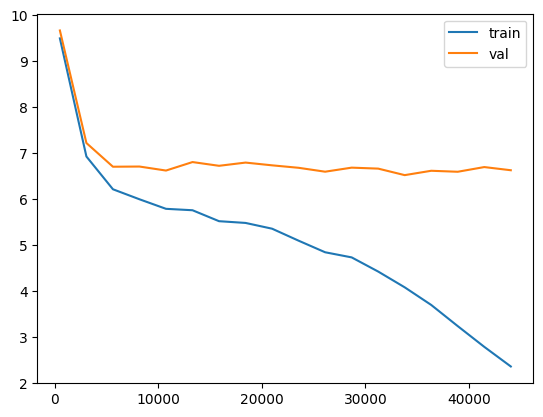

In [ ]:
import matplotlib.pyplot as plt
plt.plot(track_tokens_seen,train_losses,label="train")
plt.plot(track_tokens_seen,val_losses,label="val")
plt.legend()

In [ ]:
eos_id=50256
def generate(model,idx,max_new_tokens,context_size,top_k=None,temperature=0):
  for _ in range(max_new_tokens):
    idx_cond=idx[:,-context_size:]
    with torch.no_grad():
      logits=model(idx_cond)
    logits=logits[:,-1,:]

    if top_k is not None:
      top_logits,_=torch.topk(logits,k=top_k)
      min_val=top_logits[:,-1]
      logits=torch.where(logits<min_val,torch.tensor(float("-inf")).to(logits.device),logits)
    if temperature>0.0:
      logits=logits/temperature

      probs=torch.softmax(logits,dim=-1)
      idx_next=torch.multinomial(probs,num_samples=1)
    else:
      idx_next=torch.argmax(logits,dim=-1,keepdim=True)

    if idx_next==eos_id:
      break

    idx=torch.cat((idx,idx_next),dim=1)

  return idx


In [ ]:
tokenizer=tiktoken.get_encoding("gpt2")
token_ids=generate(
    model=model,
    idx=text_to_token_ids("every effort moves you",tokenizer).to(device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=10,
    temperature=1.4
)
print(token_ids_to_text(token_ids,tokenizer))

every effort moves you know
"
"Oh a little sit paint just Jack a tI


#coding gpt2 orginal model from hugging face pytorch


In [ ]:
!pip install -U transformers

  Using cached transformers-5.5.0-py3-none-any.whl.metadata (32 kB)
Using cached transformers-5.5.0-py3-none-any.whl (10.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 96.0 MB/s eta 0:00:00
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.4.2
    Uninstalling hf-xet-1.4.2:
      Successfully uninstalled hf-xet-1.4.2
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.15.2
    Uninstalling tokenizers-0.15.2:
      Successfully uninstalled tokenizers-0.15.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.38.0
    Uninstalling transformers-4.38

In [ ]:
import json
import os
import urllib
import ssl

def download_and_load_file(file_path, url):
    ssl_context = ssl.create_default_context()
    ssl_context.check_hostname = False
    ssl_context.verify_mode = ssl.CERT_NONE

    if not os.path.exists(file_path):
        with urllib.request.urlopen(url, context=ssl_context) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data


file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))


Number of entries: 1100


In [ ]:
data[0]

{'instruction': 'Evaluate the following phrase by transforming it into the spelling given.',
 'input': 'freind --> friend',
 'output': 'The spelling of the given phrase "freind" is incorrect, the correct spelling is "friend".'}

In [ ]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel, Trainer, TrainingArguments
import torch

In [ ]:
tokenizer=GPT2Tokenizer.from_pretrained("gpt2")
model=GPT2LMHeadModel.from_pretrained("gpt2")
# model=GPT2LMHeadModel.from_pretrained("gpt2-medium") ye bhi kar sakta

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [ ]:
tokenizer.pad_token=tokenizer.eos_token
model.config.pad_token_id=tokenizer.eos_token_id

In [ ]:
ma=-100
for e in data:
  prompt=f"instruction : {e['instruction']}\ninput : {e['input']}\noutput : {e['output']}"
  ma=max(len(prompt),ma)

print(ma)

320


In [ ]:
from sklearn.model_selection import train_test_split
train_data,val_data=train_test_split(data,test_size=0.1,random_state=42)

In [ ]:
import torch

class MyDataset(torch.utils.data.Dataset):
    def __init__(self, data, tokenizer, max_length=100):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length   # fixed length (best practice)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        example = self.data[idx]

        # Prompt (no answer yet)
        prompt = f"###Instruction: {example['instruction']}\n ###Input: {example['input']}\n ###Response:"

        # Full text (what model sees)
        full_text = prompt + " " + example["output"]

        # Tokenize full text
        tokenized_text = self.tokenizer(
            full_text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        input_ids = tokenized_text["input_ids"][0]
        attention_mask = tokenized_text["attention_mask"][0]

        # Tokenize only prompt to mask it
        prompt_ids = self.tokenizer(
            prompt,
            max_length=self.max_length,
            truncation=True
        )["input_ids"]

        # Labels = copy of input_ids
        labels = input_ids.clone()

        # Mask prompt part (no loss here)
        labels[:len(prompt_ids)] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }

In [ ]:
train_dataset = MyDataset(train_data, tokenizer)
val_dataset = MyDataset(val_data, tokenizer)

In [ ]:
model.train()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [ ]:

for p in model.parameters():
    p.requires_grad = False

k = 2
for layer in model.transformer.h[-k:]:
    for p in layer.parameters():
        p.requires_grad = True


for p in model.lm_head.parameters():
    p.requires_grad = True

In [ ]:
from transformers import TrainingArguments

# ye bhi badiya
# training_args = TrainingArguments(
#     output_dir="./results",
#     per_device_train_batch_size=2,
#     num_train_epochs=5,
#     # max_steps=500, if ye likega toh num epoch ignore
#     learning_rate=0.001,

#     logging_strategy="no",   # logs band
#     save_strategy="no",      #  checkpoints band
#     logging_strategy="steps",   # enable logging means ki loss print hoga har 10 ke step pe
#     logging_steps=10,           #  har 10 step pe loss

#     report_to="none"         #  wandb / tensorboard band
# )

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",

    per_device_train_batch_size=12,
    gradient_accumulation_steps=4,

    num_train_epochs=15,
    learning_rate=0.0001,

    # 🔥 LOGGING (train loss)
    logging_strategy="steps",
    logging_steps=20,

    # 🔥 VALIDATION
    eval_strategy="steps",   # ya "epoch"
    eval_steps=50,                 # har 50 step pe val loss

    save_strategy="no",
    report_to="none"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)
trainer.train()


Step,Training Loss,Validation Loss
50,0.368729,0.261650
100,0.251140,0.245086
150,0.223145,0.239987
200,0.190237,0.239559
250,0.183909,0.239703
300,0.168610,0.239149
315,0.168610,0.239159


TrainOutput(global_step=315, training_loss=0.3225463034614684, metrics={'train_runtime': 386.8822, 'train_samples_per_second': 38.384, 'train_steps_per_second': 0.814, 'total_flos': 757848960000000.0, 'train_loss': 0.3225463034614684, 'epoch': 15.0})

run time restart

In [ ]:
model.eval()

prompt = "###Instruction:corrct the spellings \n###Input: is this correct spelling ""Jker""\n###Response:"

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

outputs = model.generate(
    input_ids=inputs["input_ids"],
    attention_mask=inputs["attention_mask"],
    max_new_tokens=100,   # better than max_length

    do_sample=True,       # 🔥 MUST (randomness ON)

    temperature=0.8,      # randomness control
    top_k=50,             # top-k sampling
    top_p=0.9             # nucleus sampling
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


###Instruction:corrct the spellings 
###Input: is this correct spelling Jker
###Response: The corrected spelling is incorrect


In [ ]:
model.save_pretrained("./my_model")
tokenizer.save_pretrained("./my_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
import shutil

shutil.make_archive("my_model", 'zip', "./my_model")

'/content/my_model.zip'

In [ ]:
from google.colab import files
files.download("my_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#maan le yaha se model download ke baad kahi use toh ye kar

bas aone model ko unzip kar uss mymodel wali file ko and bas kaam ho gaya and sabse zaruri baat andar koi mode ni hai mymodel ke usme uss model ki confhg hai and aise load



```
from fastapi import FastAPI
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

app = FastAPI()

model = GPT2LMHeadModel.from_pretrained("./my_model")
tokenizer = GPT2Tokenizer.from_pretrained("./my_model")

@app.get("/generate")
def generate(instruction: str, input_text: str):
    prompt = f"""### Instruction:
{instruction}

### Input:
{input_text}

### Response:
"""

    inputs = tokenizer(prompt, return_tensors="pt")

    output = model.generate(
        **inputs,
        max_new_tokens=100
    )

    return {"response": tokenizer.decode(output[0], skip_special_tokens=True)}
```



ye do chat gpt use kiya for refrnce


ye main
 [link text](https://chatgpt.com/share/69d3c141-f0e0-8324-8e03-4b22fb1b863f)


isme for working understand
 [link text](https://chatgpt.com/share/69d3c1c3-9208-8323-8e0d-4f8a98e3a076)

